# 2 Comparación de modelos

## 2.1 Importación y configuración

In [54]:
from IPython.display import display, HTML, Markdown
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import optuna.visualization as vis
import joblib
import xgboost as xgb
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from utils.optuna_utils import get_random_forest_objective, get_xgboost_objective
from sklearn.model_selection import KFold
from sklearn.metrics import (mean_absolute_error, r2_score,
                             root_mean_squared_error,
                             mean_absolute_percentage_error)
from utils.config import PROCESSED_FILE_PATH, RANDOM_FOREST_MODEL_PATH, TEST_SIZE, RANDOM_STATE, XGBOOST_MODEL_PATH, BASE_DIR, render_physics_table
cols_continuas = [
    # Electrón 1
    'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1',
    # Electrón 2
    'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2',
    # Variables Físicas que creamos
    'E_total', 'delta_eta', 'delta_phi', 'delta_R', 
    'pt_product', 'pt_ratio'
]
# Las que son -1, 1 o 0 no necesitan StandardScaler, se dejan como están.
cols_discretas = ['Q1', 'Q2', 'is_os']
MODELS_PATH = Path(BASE_DIR) / "models"
MODELS_PATH.mkdir(parents=True, exist_ok=True)

## 2.2 Estandarización

In [15]:
df = pd.read_parquet(PROCESSED_FILE_PATH)
X = df.drop(columns=['M'])
y = df['M']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=TEST_SIZE, random_state=RANDOM_STATE)
display(render_physics_table(X_train.head(5),"Vista previa del Dataset de Entrenamiento (Variables Físicas)"))
display(render_physics_table(X_test.head(5),"Vista previa del Dataset de Testeo (Variables Físicas)"))

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,delta_eta,delta_phi,delta_R,pt_product,pt_ratio,E_total,is_os
39753,6.0381,-1.3699,3.5867,-4.6602,3.8394,-1.0248,1.9356,-1,2.6496,-2.0509,-1.5793,-0.5655,2.5885,-0.2168,-2.4854,1,0.8080,1.8621,2.0299,9.9382,1.4832,8.6876,1
30621,19.2083,5.6819,17.2794,-6.1722,18.1896,-0.3331,1.2531,-1,10.7579,2.0969,-2.3983,10.2754,3.1857,1.8874,-0.8524,1,2.2206,2.1055,3.0600,57.9466,5.7098,29.9662,1
77135,32.4649,2.7509,-15.8061,28.2236,16.0436,1.3304,-1.3985,1,13.9656,-2.6723,4.0731,13.0885,4.8714,1.7145,2.1514,1,0.3840,2.7333,2.7601,78.1554,3.2934,46.4305,0
98111,29.1802,0.3083,19.2675,-21.9123,19.2700,-0.9751,1.5548,-1,63.0005,-6.4890,-18.1246,59.9871,19.2512,1.8545,-1.9146,-1,2.8296,2.8138,3.9905,370.9706,1.0010,92.1807,0
8879,98.5175,3.9101,-30.1036,93.7240,30.3565,1.8457,-1.4416,-1,10.4315,-0.1977,2.7699,-10.0551,2.7769,-1.9984,1.6421,1,3.8442,3.0837,4.9282,84.2973,10.9318,108.9490,1


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,delta_eta,delta_phi,delta_R,pt_product,pt_ratio,E_total,is_os
41651,78.2504,-3.4400,13.5212,-76.9965,13.9519,-2.4094,1.8199,1,40.2585,0.9387,-6.5986,-39.7029,6.6651,-2.4847,-1.4295,-1,0.0753,3.0338,3.0347,92.9903,2.0933,118.5089,1
27556,33.4144,-8.6356,2.0210,-32.2159,8.8689,-2.0015,2.9117,1,12.5369,1.3845,2.6244,-12.1807,2.9672,-2.1199,1.0853,1,0.1184,1.8264,1.8302,26.3156,2.9890,45.9513,0
81172,12.6575,-0.4657,-12.6450,0.3180,12.6536,0.0251,-1.6076,-1,6.9564,0.8071,6.6413,-1.9059,6.6902,-0.2812,1.4499,1,0.3063,3.0575,3.0728,84.6550,1.8914,19.6139,1
76512,29.6082,22.9165,-5.3821,-17.9587,23.5400,-0.7034,-0.2307,1,20.5149,-18.7714,-3.6853,-7.4105,19.1297,-0.3783,-2.9477,-1,0.3251,2.7171,2.7364,450.3131,1.2305,50.1231,1
34719,61.8255,-11.8102,11.4192,59.6030,16.4280,2.0003,2.3730,1,36.1831,2.2768,-7.0527,35.4159,7.4111,2.2681,-1.2585,-1,0.2678,2.6516,2.6651,121.7494,2.2167,98.0086,1


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        # Aplicamos StandardScaler a las continuas
        ('num', StandardScaler(), cols_continuas),
        
        # Dejamos las de carga y binarias tal cual (passthrough)
        ('bin', 'passthrough', cols_discretas)
    ],
    remainder='drop'
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

columnas_reales = preprocessor.get_feature_names_out()

# Armamos los DataFrames con los nombres correctos que entrega el preprocessor
df_train_scaled = pd.DataFrame(X_train_scaled, columns=columnas_reales)
df_test_scaled = pd.DataFrame(X_test_scaled, columns=columnas_reales)

display(render_physics_table(df_train_scaled.head(5),"Vista previa del Dataset de Entrenamiento Escalado (Variables Físicas)"))
display(render_physics_table(df_test_scaled.head(5),"Vista previa del Dataset de Testeo Escalado (Variables Físicas)"))

,num__E1,num__px1,num__py1,num__pz1,num__pt1,num__eta1,num__phi1,num__E2,num__px2,num__py2,num__pz2,num__pt2,num__eta2,num__phi2,num__E_total,num__delta_eta,num__delta_phi,num__delta_R,num__pt_product,num__pt_ratio,bin__Q1,bin__Q2,bin__is_os
0,-1.1818,-0.0848,0.1965,-0.0298,-1.5183,-0.5781,1.0594,-0.6380,-0.2721,-0.2209,0.0104,-0.5107,-0.0886,-1.3773,-1.2529,-0.5663,-0.0841,-0.5634,-0.4574,-0.8744,-1.0000,1.0000,1.0000
1,-0.9084,0.3242,0.9890,-0.0498,-0.2826,-0.1638,0.6810,-0.2881,0.2812,-0.3290,0.4124,-0.4380,1.2792,-0.4774,-0.8812,0.5559,0.1602,0.3066,-0.3388,0.0580,-1.0000,1.0000,1.0000
2,-0.6333,0.1542,-0.9259,0.4063,-0.4674,0.8327,-0.7892,-0.1498,-0.3550,0.5251,0.5168,-0.2330,1.1667,1.1777,-0.5936,-0.9032,0.7906,0.0533,-0.2889,-0.4751,1.0000,1.0000,0.0000
3,-0.7015,0.0125,1.1041,-0.2586,-0.1896,-0.5483,0.8482,1.9657,-0.8641,-2.4046,2.2562,1.5164,1.2578,-1.0627,0.2056,1.0398,0.8715,1.0924,0.4343,-0.9808,-1.0000,-1.0000,0.0000
4,0.7377,0.2214,-1.7534,1.2750,0.7651,1.1413,-0.8131,-0.3022,-0.0249,0.3531,-0.3416,-0.4878,-1.2466,0.8970,0.4985,1.8458,1.1425,1.8844,-0.2738,1.2099,-1.0000,1.0000,1.0000


,num__E1,num__px1,num__py1,num__pz1,num__pt1,num__eta1,num__phi1,num__E2,num__px2,num__py2,num__pz2,num__pt2,num__eta2,num__phi2,num__E_total,num__delta_eta,num__delta_phi,num__delta_R,num__pt_product,num__pt_ratio,bin__Q1,bin__Q2,bin__is_os
0,0.3171,-0.2049,0.7715,-0.9891,-0.6475,-1.4075,0.9952,0.9846,0.1267,-0.8834,-1.4412,-0.0148,-1.5627,-0.7954,0.6655,-1.1484,1.0924,0.2852,-0.2523,-0.7398,1.0000,-1.0000,1.0000
1,-0.6136,-0.5062,0.1059,-0.3952,-1.0852,-1.1631,1.6006,-0.2114,0.1862,0.3339,-0.4204,-0.4646,-1.3256,0.5903,-0.6020,-1.1142,-0.1200,-0.7320,-0.4170,-0.5422,1.0000,1.0000,0.0000
2,-1.0444,-0.0324,-0.7430,0.0362,-0.7593,0.0508,-0.9052,-0.4521,0.1091,0.8641,-0.0393,-0.0117,-0.1304,0.7911,-1.0621,-0.9649,1.1162,0.3174,-0.2729,-0.7843,-1.0000,1.0000,1.0000
3,-0.6926,1.3237,-0.3226,-0.2062,0.1781,-0.3856,-0.1417,0.1328,-2.5024,-0.4989,-0.2435,1.5016,-0.1935,-1.6320,-0.5291,-0.9499,0.7743,0.0333,0.6302,-0.9301,1.0000,-1.0000,1.0000
4,-0.0239,-0.6903,0.6498,0.8225,-0.4343,1.2339,1.3019,0.8088,0.3052,-0.9433,1.3449,0.0760,1.5266,-0.7012,0.3074,-0.9955,0.7087,-0.0269,-0.1813,-0.7126,1.0000,-1.0000,1.0000


## 2.3 Implementación del modelo Decision Tree Regressor

### 2.3.1 Creación del árbol de regresión
Como etapa exploratoria, se entrenó un árbol sin restricciones (min_samples_leaf=1). Este experimento permitió confirmar la tendencia del modelo al sobreajuste (overfitting), donde la estructura alcanza su máxima complejidad estructural al intentar memorizar cada observación. Si bien el costo computacional es bajo para este volumen de datos, el modelo pierde toda capacidad de generalización al capturar el ruido intrínseco de la muestra.

In [17]:
# Creamos el arbol
regression_orig = DecisionTreeRegressor(criterion='squared_error', splitter='best', 
                                   max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                                   random_state=RANDOM_STATE)
# Y entrenamos (los árboles de decisión son invariantes a la escala)
regression_orig.fit(X_train_scaled, y_train)

DecisionTreeRegressor(random_state=42)

### 2.3.2 Medición de performance inicial

In [18]:
# Cálculo de métricas baseline
y_pred_train = regression_orig.predict(X_train_scaled)
y_pred = regression_orig.predict(X_test_scaled)

mae_train_dt = mean_absolute_error(y_train, y_pred_train)
mae_dt = mean_absolute_error(y_test, y_pred)
rmse_dt = root_mean_squared_error(y_test, y_pred)
mape_dt = mean_absolute_percentage_error(y_test, y_pred)
r2_dt = r2_score(y_test, y_pred)

In [19]:
# Mensaje informativo de métricas baseline
html_metricas_baseline = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 600px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5);">

    <div style="display: flex; align-items: center; margin-bottom: 15px; border-bottom: 1px solid #f56565; padding-bottom: 10px;">
        <span style="font-size: 20px; margin-right: 12px;">📉</span>
        <h3 style="color: #ffffff; margin: 0;">Métricas del modelo Baseline</h3>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px;">
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #f56565;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAE de entrenamiento</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_train_dt:.2f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #f56565;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_dt:.2f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #f56565;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">RMSE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{rmse_dt:.4f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #f56565;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAPE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mape_dt:.2f}</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #f56565;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">R² Score</span>
            <b style="color: #ffffff; font-size: 1.1em;">{r2_dt:.4f}</b>
        </div>
    </div>
</div>
"""
display(HTML(html_metricas_baseline))

Estos resultados confirman nuestra afirmación inicial sobre el sobreajuste al haber elegido entrenar un árbol sin restricciones.

### 2.3.3 Comparación con un modelo de regresión lineal como baseline

In [20]:
# Ejecución regrtesión lineal y obtención de métricas
regresion_lineal = LinearRegression()
regresion_lineal.fit(X_train_scaled, y_train)
y_pred_lineal = regresion_lineal.predict(X_test_scaled)
mae_rl = mean_absolute_error(y_test, y_pred_lineal)
rmse_rl = root_mean_squared_error(y_test, y_pred_lineal)
mape_rl = mean_absolute_percentage_error(y_test, y_pred_lineal)
r2_rl = r2_score(y_test, y_pred_lineal)

In [21]:
# Mensaje informativo de métricas de regresión lineal
html_metricas_lineal = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 600px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5); margin-left: 0;">

    <div style="display: flex; align-items: center; margin-bottom: 15px; border-bottom: 1px solid #48bb78; padding-bottom: 10px;">
        <span style="font-size: 20px; margin-right: 12px;">📊</span>
        <h3 style="color: #ffffff; margin: 0;">Métricas de Regresión Lineal</h3>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px;">
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #48bb78;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_rl:.2f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #48bb78;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">RMSE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{rmse_rl:.4f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #48bb78;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAPE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mape_rl:.2%}</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #48bb78;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">R² Score</span>
            <b style="color: #ffffff; font-size: 1.1em;">{r2_rl:.4f}</b>
        </div>
    </div>
</div>
"""
display(HTML(html_metricas_lineal))

### 2.3.4 Comparación con un modelo que predice usando el promedio

In [22]:
# ¿Qué pasa si siempre predigo el promedio?
y_promedio = np.full_like(y_test, fill_value=y_train.mean())

mae_prom = mean_absolute_error(y_test, y_promedio)
rmse_prom = root_mean_squared_error(y_test, y_promedio)
mape_prom = mean_absolute_percentage_error(y_test, y_promedio)
r2_prom = r2_score(y_test, y_promedio)

In [23]:
html_metricas_promedio = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 600px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5); margin-left: 0;">

    <div style="display: flex; align-items: center; margin-bottom: 15px; border-bottom: 1px solid #9f7aea; padding-bottom: 10px;">
        <span style="font-size: 20px; margin-right: 12px;">⚖️</span>
        <h3 style="color: #ffffff; margin: 0;">Métricas del Modelo Promedio</h3>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px;">
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #9f7aea;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_prom:.2f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #9f7aea;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">RMSE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{rmse_prom:.2f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #9f7aea;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAPE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mape_prom:.2%}</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #9f7aea;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">R² Score</span>
            <b style="color: #ffffff; font-size: 1.1em;">{r2_prom:.6f}</b>
        </div>
    </div>

    <p style="color: #a0aec0; font-size: 0.8em; margin-top: 15px; font-style: italic;">
        Nota: Un R² cercano a 0 indica que las predicciones del modelo no tienen utilidad real. El modelo no encuentra un patrón útil en los datos
    </p>
</div>
"""

display(HTML(html_metricas_promedio))

### 2.3.5 Validación cruzada

In [24]:
# Hagamos una ejecución de prueba
clf = DecisionTreeRegressor(criterion='squared_error', splitter='best', 
                            max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                            random_state=RANDOM_STATE, ccp_alpha=0)

scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, 
                         scoring='neg_mean_absolute_error', n_jobs=-1)
scores = np.abs(scores)

In [25]:
html_scores_cv = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 600px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5); margin-left: 0;">

    <div style="display: flex; align-items: center; margin-bottom: 15px; border-bottom: 1px solid #ecc94b; padding-bottom: 10px;">
        <span style="font-size: 20px; margin-right: 12px;">🧪</span>
        <h3 style="color: #ffffff; margin: 0;">Validación Cruzada</h3>
    </div>

    <div style="margin-bottom: 20px;">
        <span style="color: #a0aec0; font-size: 0.85em; display: block; margin-bottom: 8px;">Scores por Fold (MAE):</span>
        <div style="display: flex; gap: 8px; flex-wrap: wrap;">
            {''.join([f'<span style="background: rgba(236,201,75,0.1); color: #ecc94b; padding: 4px 10px; border-radius: 4px; border: 1px solid rgba(236,201,75,0.3); font-weight: bold;">{s:.4f}</span>' for s in scores])}
        </div>
    </div>

    <div style="padding: 15px; background-color: rgba(236,201,75,0.05); border-radius: 8px; border-left: 4px solid #ecc94b;">
        <span style="color: #a0aec0; font-size: 0.85em; display: block;">Valor Medio de MAE</span>
        <b style="color: #ffffff; font-size: 1.4em;">{np.mean(scores):.4f} GeV</b>
        <p style="color: #a0aec0; font-size: 0.8em; margin: 5px 0 0 0; font-style: italic;">
            Consistencia del modelo detectada con parámetro de complejidad ccp_alfa = 0.
        </p>
    </div>
</div>
"""
display(HTML(html_scores_cv))

### 2.3.6 Corrección del modelo aplicando restricciones sobre Cost-Complexity Pruning Alpha
Se utilizó cost_complexity_pruning_path para identificar el rango de valores de alfa relevantes para el modelo. Dado que el árbol genera una alta densidad de alfas cercanos a cero y valores extremos al final del proceso de poda, se definió un rango acotado y equidistante de alfas (entre 0 y 0.1) para garantizar una visualización clara y útil. Luego, se aplicó GridSearchCV con validación cruzada ($CV=5$) sobre este rango para evaluar el MAE y detectar el alfa óptimo. Finalmente, se graficó Alpha vs MAE (incluyendo desviación estándar), permitiendo identificar con precisión el punto donde se minimiza el error y se logra el mejor balance entre sesgo y varianza, evitando que los valores atípicos de la poda distorsionen la escala del gráfico.

In [26]:
# Calculamos el path pero filtramos los alfas absurdos
clf_full = DecisionTreeRegressor(random_state=42)
path = clf_full.cost_complexity_pruning_path(X_train_scaled, y_train)

# Filtramos: solo alfas menores a 0.1 (que es donde suele estar el óptimo)
# Y de esos, tomamos 20 puntos parejos para que el gráfico sea legible
alphas_filtrados = path.ccp_alphas[path.ccp_alphas < 0.1]
indices = np.linspace(0, len(alphas_filtrados) - 1, 40).astype(int)
alpha_real = alphas_filtrados[indices]

# GridSearch con este rango lógico
param_grid = {'ccp_alpha': alpha_real}
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

res = grid.cv_results_
df_results = pd.DataFrame({
    "alpha": alpha_real,
    "mae1": np.abs(res["split0_test_score"]),
    "mae2": np.abs(res["split1_test_score"]),
    "mae3": np.abs(res["split2_test_score"]),
    "mae4": np.abs(res["split3_test_score"]),
    "mae5": np.abs(res["split4_test_score"])
})

df_plot = pd.melt(df_results, id_vars=['alpha'], 
                  value_vars=["mae1", "mae2", "mae3", "mae4", "mae5"],
                  var_name='fold', value_name='mae_val')

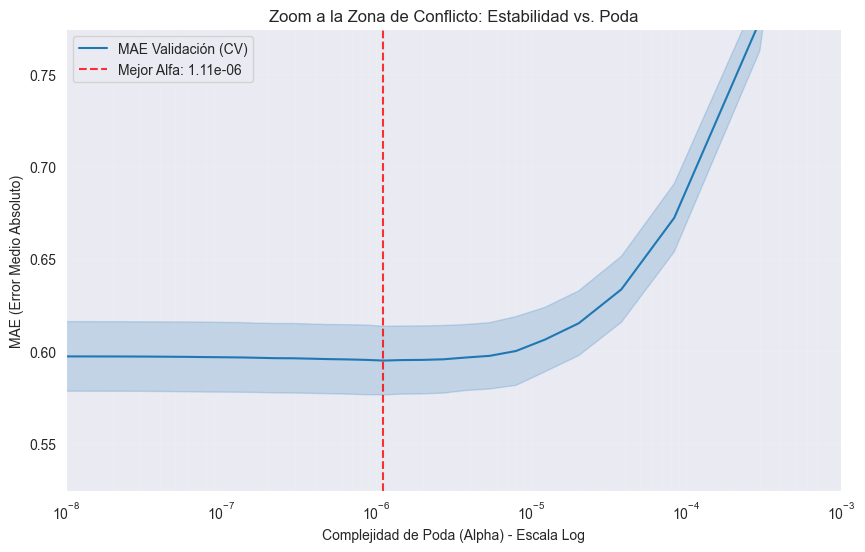

In [27]:
alfa_min_ver = 1e-8
alfa_max_ver = 1e-3 

f, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_plot, x="alpha", y="mae_val", errorbar="sd", ax=ax, label="MAE Validación (CV)")

ax.set_xscale('log')  # Escala logarítmica

# El mejor alfa real
mejor_alfa_encontrado = grid.best_params_['ccp_alpha']
ax.axvline(mejor_alfa_encontrado, color="red", linestyle="--", alpha=0.8,
           label=f"Mejor Alfa: {mejor_alfa_encontrado:.2e}")

ax.set_xlim([alfa_min_ver, alfa_max_ver])
ax.set_ylim([df_plot["mae_val"].min() - 0.05, df_plot["mae_val"].min() + 0.2])

ax.set_xlabel("Complejidad de Poda (Alpha) - Escala Log")
ax.set_ylabel("MAE (Error Medio Absoluto)")
ax.set_title("Zoom a la Zona de Conflicto: Estabilidad vs. Poda")
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.1)

plt.show()

In [28]:
# Creamos el arbol
# Podemos usar alfa = mejor_alfa_encontrado o un valor de compromiso como 1e-4
regression_mejorado = DecisionTreeRegressor(criterion='squared_error', splitter='best', 
                                   max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                                   random_state=RANDOM_STATE, ccp_alpha=1e-4)
# Y entrenamos
regression_mejorado.fit(X_train_scaled, y_train)

y_pred_train = regression_mejorado.predict(X_train_scaled)
y_pred = regression_mejorado.predict(X_test_scaled)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [29]:
html_metricas_arbol_poda = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 600px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5); margin-left: 0;">

    <div style="display: flex; align-items: center; margin-bottom: 15px; border-bottom: 1px solid #ed64a6; padding-bottom: 10px;">
        <span style="font-size: 20px; margin-right: 12px;">🌳</span>
        <h3 style="color: #ffffff; margin: 0;">Métricas del método de regresión mejorado</h3>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px;">
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #ed64a6;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAE Entrenamiento</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_train:.4f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #ed64a6;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAE Testeo</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae:.4f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #ed64a6;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">RMSE Testeo</span>
            <b style="color: #ffffff; font-size: 1.1em;">{rmse:.4f} GeV</b>
        </div>
        <div style="padding: 10px; background-color: rgba(255,255,255,0.03); border-radius: 6px; border-left: 3px solid #ed64a6;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">R² Score</span>
            <b style="color: #ffffff; font-size: 1.1em;">{r2:.4f}</b>
        </div>
    </div>

    <div style="margin-top: 15px; padding: 10px; background-color: rgba(237,100,166,0.05); border-radius: 6px;">
        <span style="color: #a0aec0; font-size: 0.8em; display: block;">MAPE de Testeo</span>
        <b style="color: #ed64a6; font-size: 1.2em;">{mape:.4f}</b>
    </div>

    <p style="color: #a0aec0; font-size: 0.8em; margin-top: 15px; font-style: italic;">
        Nota: El uso de ccp_alpha=0.0004 permitió reducir la complejidad del árbol sin sacrificar el alto poder predictivo (R² > 0.99).
    </p>
</div>
"""
display(HTML(html_metricas_arbol_poda))

In [30]:
def info_arbol(modelo):
    n_hojas = modelo.get_n_leaves()
    profundidad = modelo.get_depth()
    return n_hojas, profundidad

# Calculamos
hojas_orig, prof_orig = info_arbol(regression_orig)
hojas_poda, prof_poda = info_arbol(regression_mejorado)

# Porcentaje de reducción
reduccion = (1 - hojas_poda/hojas_orig) * 100

In [31]:
html_optimizacion = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 650px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5); margin-left: 0;">

    <div style="display: flex; align-items: center; margin-bottom: 15px; border-bottom: 1px solid #f6ad55; padding-bottom: 10px;">
        <span style="font-size: 20px; margin-right: 12px;">🛠️</span>
        <h3 style="color: #ffffff; margin: 0;">Optimización y Estabilidad estructural</h3>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin-bottom: 20px;">
        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-top: 3px solid #ed64a6;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">Árbol Original (Overfit)</span>
            <b style="color: #ffffff; font-size: 1em;">{hojas_orig} hojas</b><br>
            <span style="color: #718096; font-size: 0.85em;">Profundidad: {prof_orig}</span>
        </div>
        <div style="padding: 12px; background-color: rgba(72,187,120,0.1); border-radius: 8px; border-top: 3px solid #48bb78;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block;">Árbol Podado (Mejor Alfa)</span>
            <b style="color: #ffffff; font-size: 1em;">{hojas_poda} hojas</b><br>
            <span style="color: #48bb78; font-size: 0.85em;">Profundidad: {prof_poda}</span>
        </div>
    </div>

    <div style="background-color: rgba(246,173,85,0.1); padding: 10px; border-radius: 6px; text-align: center; margin-bottom: 20px;">
        <span style="color: #f6ad55; font-weight: bold;">Reducción de complejidad: {reduccion:.2f}%</span>
    </div>
</div>
"""
display(HTML(html_optimizacion))

El análisis de la curva de complejidad frente al error de validación (CV) revela una meseta de rendimiento donde la reducción del error es marginal frente al crecimiento del árbol. Se optó por un valor de `ccp_alpha` superior al que genera el error mínimo basándose en los siguientes criterios:

* **Compromiso Estructura-Error:** Se seleccionó un punto de poda que permitió reducir las hojas de ~80k a ~4k. Si bien esto implica un MAE ligeramente superior, evita la "fragmentación" del espacio de fases, eliminando miles de subdivisiones que no aportan ganancia de información significativa.
* **De Tabla de Búsqueda a Predictor:** El árbol original actuaba como una *lookup table*, memorizando eventos específicos. La poda agresiva fuerza al modelo a generalizar, resultando en una función de decisión por escalones que agrupa eventos con características cinemáticas similares, siendo más coherente con la resolución física del detector.
* **Eficiencia Computacional:** El modelo final es más eficiente, optimizando los tiempos de inferencia sin sacrificar la capacidad de identificar las resonancias (picos de masa) del dataset.

### 2.3.7 Random Forest con estimación de hiperparámetros

In [32]:
html_intro = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #161e2e;
            border: 1px solid #2d3748; border-radius: 12px; width: 100%; max-width: 800px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.4);">

    <div style="border-bottom: 1px solid #4299e1; padding-bottom: 10px; margin-bottom: 15px;">
        <h2 style="color: #ffffff; margin: 0;">🛠️ Fase de Optimización de Hiperparámetros de Random Forest</h2>
    </div>

    <p style="color: #e2e8f0; line-height: 1.6;">
        En esta etapa, se utiliza el framework <b>Optuna</b> para realizar una búsqueda bayesiana
        sobre el espacio de configuración del modelo <code>RandomForestRegressor</code>.
    </p>

    <div style="background-color: rgba(66, 153, 225, 0.1); padding: 15px; border-radius: 8px; border-left: 5px solid #4299e1;">
        <h4 style="color: #63b3ed; margin-top: 0;">🎯 Objetivo de Optimización</h4>
        <p style="color: #a0aec0; font-size: 0.95em; margin-bottom: 0;">
            La meta es <b>minimizar</b> la métrica <b>RMSE (Root Mean Squared Error)</b>.
            Físicamente, esto representa reducir la incertidumbre en la reconstrucción de la masa invariante
            (GeV), ajustando las capacidades de generalización del modelo frente a los datos del CERN.
        </p>
    </div>

    <div style="margin-top: 15px; display: flex; gap: 10px; color: #718096; font-size: 0.85em;">
        <span>🔍 Algoritmo: TPESampler</span> |
        <span>📊 Métrica: neg_mean_squared_error</span> |
        <span>🚀 Dirección: Minimize</span>
    </div>
</div>
"""

display(HTML(html_intro))

In [33]:
# Creación de y_sample, X_train_scaled_sample y kFold.
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
indices = np.random.choice(X_train_scaled.shape[0], 20000, replace=False)
X_train_scaled_sample = X_train_scaled[indices]
y_sample = y_train.iloc[indices].values

In [34]:
# Búsqueda de hiperparámetros de Random Forest óptimos con optuna.
study = optuna.create_study(direction="minimize", study_name="estimacion_masa_invariante_rf")
obj_func = get_random_forest_objective(X_train_scaled_sample, y_sample, kf)
study.optimize(obj_func, n_trials=20)

[I 2026-04-26 16:56:36,809] A new study created in memory with name: estimacion_masa_invariante_rf
[I 2026-04-26 16:57:28,947] Trial 0 finished with value: 1.4561028947792272 and parameters: {'n_estimators': 362, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': None}. Best is trial 0 with value: 1.4561028947792272.
[I 2026-04-26 16:57:38,755] Trial 1 finished with value: 2.99717989694599 and parameters: {'n_estimators': 312, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 1.4561028947792272.
[I 2026-04-26 16:57:46,110] Trial 2 finished with value: 2.7416216610179434 and parameters: {'n_estimators': 204, 'max_depth': 36, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.4561028947792272.
[I 2026-04-26 16:58:01,425] Trial 3 finished with value: 2.744134674725003 and parameters: {'n_estimators': 456, 'max_depth': 34, 'min_samples_split':

In [35]:
# Gráfico de optimización del valor objetivo (RMSE)
vis.plot_optimization_history(study).show()
#Gráfico de importancia de los hiperparámetros de Random Forest.
vis.plot_param_importances(study).show()

In [36]:
# Cartel de visualización del análisis de hiperparámetros de Random Forest.
rmse_inicial_rf = study.trials[0].value
rmse_mejor_rf = study.best_value
total_trials_rf = len(study.trials)
importancias_rf = optuna.importance.get_param_importances(study)
param_top_rf = list(importancias_rf.keys())[0]
valor_top_rf = importancias_rf[param_top_rf] * 100

html_analisis_hiperparmetros = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #161e2e;
            border: 1px solid #2d3748; border-radius: 12px; width: 100%; max-width: 800px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.4);">

    <div style="border-bottom: 1px solid #2d3748; padding-bottom: 10px; margin-bottom: 15px;">
        <h3 style="color: #63b3ed; margin: 0;">📊 Análisis de Optimización de Hiperparámetros (Random Forest)</h3>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
        <div style="background-color: #1a202c; padding: 15px; border-radius: 8px; border-left: 4px solid #4299e1;">
            <h4 style="color: #e2e8f0; margin-top: 0;">Historial de optimización</h4>
            <p style="color: #a0aec0; font-size: 0.9em; line-height: 1.5;">
                El proceso muestra una convergencia clara. El modelo inició con un
                <b>RMSE de {rmse_inicial_rf:.4f} GeV</b> y, tras {total_trials_rf} iteraciones,
                logró reducir la incertidumbre hasta un mínimo estable de <b>{rmse_mejor_rf:.4f} GeV</b>.
            </p>
        </div>

        <div style="background-color: #1a202c; padding: 15px; border-radius: 8px; border-left: 4px solid #ed8936;">
            <h4 style="color: #e2e8f0; margin-top: 0;">Importancia de Parámetros</h4>
            <p style="color: #a0aec0; font-size: 0.9em; line-height: 1.5;">
                Se detecta una dominancia de <b>{param_top_rf} ({valor_top_rf:.1f}%)</b>.
                Esto confirma que la capacidad de generalización depende fundamentalmente de este parámetro,
                siendo el factor determinante en la calidad de la reconstrucción física.
            </p>
        </div>
    </div>

    <div style="margin-top: 15px; padding: 10px; background-color: rgba(72, 187, 120, 0.1);
                border-radius: 6px; text-align: center;">
        <span style="color: #48bb78; font-weight: bold; font-size: 0.9em;">
            💡 Conclusión: La optimización redujo el error en un {((rmse_inicial_rf - rmse_mejor_rf) / rmse_inicial_rf)*100:.2f}% respecto al trial inicial.
        </span>
    </div>
</div>
"""

display(HTML(html_analisis_hiperparmetros))

In [37]:
# Cartel de visualización de los valores de los mejores hiperparámetros para Random Forest.
best_params = study.best_params
html_audit_panel = f"""
<div style="font-family: 'Segoe UI', system-ui, -apple-system, sans-serif;
            padding: 20px;
            background-color: #161e2e;
            border: 1px solid #2d3748;
            border-radius: 12px;
            width: fit-content;
            box-shadow: inset 0 2px 4px rgba(0,0,0,0.3);">

    <div style="display: flex; align-items: center; margin-bottom: 15px; border-bottom: 1px solid #2d3748; padding-bottom: 12px;">
        <span style="font-size: 1.3em; margin-right: 10px;">✅</span>
        <h3 style="color: #48bb78; margin: 0; font-weight: 600;">
            Mejores hiperparámetros:
        </h3>
    </div>

    <div style="color: #a0aec0; font-size: 0.95em; margin-bottom: 20px; padding: 0 10px;">
        Mejor combinación de valores para ejecutar Random Forest.
    </div>

    <table style="border-collapse: collapse; width: 340px; color: #e2e8f0; font-size: 0.95em;">
        <thead>
            <tr style="background-color: #1f2937; box-shadow: inset 0 1px 1px rgba(255,255,255,0.05);">
                <th style="padding: 12px 15px; text-align: left; border-top-left-radius: 8px; font-weight: 500;">Parámetro</th>
                <th style="padding: 12px 15px; text-align: center; border-top-right-radius: 8px; font-weight: 500;">Valor</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748;"><b>n_estimators</b></td>
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748; text-align: center; color: #4299e1;">{best_params['n_estimators']}</td>
            </tr>
            <tr style="background-color: #1a202c;">
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748;"><b>max_depth</b></td>
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748; text-align: center; color: #4299e1;">{best_params['max_depth']}</td>
            </tr>
            <tr>
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748;"><b>min_samples_split</b></td>
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748; text-align: center; color: #4299e1;">{best_params['min_samples_split']}</td>
            </tr>
            <tr style="background-color: #1a202c;">
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748;"><b>min_samples_leaf</b></td>
                <td style="padding: 10px 15px; border-bottom: 1px solid #2d3748; text-align: center; color: #4299e1;">{best_params['min_samples_leaf']}</td>
            </tr>
            <tr>
                <td style="padding: 10px 15px; border-bottom-left-radius: 8px;"><b>max_features</b></td>
                <td style="padding: 10px 15px; border-bottom-right-radius: 8px; text-align: center; font-weight: bold; color: #ed8936;">{best_params['max_features']}</td>
            </tr>
        </tbody>
    </table>

    <div style="margin-top: 20px; font-size: 0.8em; color: #718096; text-align: right; border-top: 1px solid #2d3748; padding-top: 10px;">
        Estudio: `estimacion_masa_invariante_rf` | <span style="color: #48bb78;">ESTADO: COMPLETO</span>
    </div>
</div>
"""
display(HTML(html_audit_panel))

Parámetro,Valor
n_estimators,103
max_depth,40
min_samples_split,9
min_samples_leaf,2
max_features,None


In [38]:
# Aplicación del Random Forest con los mejores hiperparámetros
# y almacenamiento parcial del modelo.
mejores_parametros = study.best_params
modelo_final_rf = RandomForestRegressor(**mejores_parametros, n_jobs=-1, random_state=RANDOM_STATE)
modelo_final_rf.fit(X_train_scaled, y_train)
print("✅ Modelo Random Forest final entrenado con los eventos de entrada.")
joblib.dump(modelo_final_rf, RANDOM_FOREST_MODEL_PATH)
print(f"💾 Modelo Random Forest guardado como {RANDOM_FOREST_MODEL_PATH}")


✅ Modelo Random Forest final entrenado con los eventos de entrada.
💾 Modelo Random Forest guardado como C:\Users\alilu\PycharmProjects\CEIA_Aprendizaje_de_maquina_tp_cern\models\invariant_mass_model_random_forest.pkl


In [39]:
# Lectura del modelo de Random Forest almacenado en disco
# y predicción de la masa invariante
modelo_rf_cargado = joblib.load(RANDOM_FOREST_MODEL_PATH)
y_pred_rf = modelo_rf_cargado.predict(X_test_scaled)
y_pred_train_rf = modelo_rf_cargado.predict(X_train_scaled)
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mape_rf=mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

MAE de entreamiento fue: 0.1342415892739066
MAE de testeo fue: 0.2506548056975443
RMSE de testeo fue: 0.6453364581617516
MAPE de testeo fue: 0.008549593529712908
R2 de testeo fue: 0.9993442287452963


In [40]:
html_metricas_rf = f"""
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            padding: 20px; background-color: #1a1a2e;
            border: 1px solid #2d3748; border-radius: 12px; width: 100%; max-width: 600px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.4);">

    <div style="display: flex; align-items: center; margin-bottom: 20px; border-bottom: 1px solid #48bb78; padding-bottom: 10px;">
        <span style="font-size: 24px; margin-right: 12px;">🌲</span>
        <div>
            <h3 style="color: #ffffff; margin: 0; font-size: 1.2em;">Random Forest (Optimizado con Optuna)</h3>
        </div>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px;">

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #48bb78;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">MAE Entrenamiento</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_train_rf:.4f} GeV</b>
        </div>

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #48bb78;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">MAE Testeo</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_rf:.4f} GeV</b>
        </div>

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #38b2ac;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">RMSE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{rmse_rf:.4f} GeV</b>
        </div>

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #38b2ac;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">MAPE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mape_rf:.4f}</b>
        </div>

        <div style="grid-column: span 2; padding: 12px; background: linear-gradient(90deg, rgba(72,187,120,0.1), transparent); border-radius: 8px; border-left: 4px solid #48bb78; margin-top: 5px;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">R² Score</span>
            <b style="color: #ffffff; font-size: 1.3em;">{r2_rf:.4f}</b>
        </div>
    </div>

    <div style="margin-top: 15px; text-align: right;">
        <span style="color: #718096; font-size: 0.75em; font-style: italic;">Ajuste global superior detectado en el espacio de parámetros.</span>
    </div>
</div>
"""
display(HTML(html_metricas_rf))

### 2.3.8 XGBoost con estimación de hiperparámetros

In [41]:
# Mensaje descriptivo de XGBoost.
html_intro_xgb = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 800px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5);">

    <div style="border-bottom: 1px solid #f39c12; padding-bottom: 10px; margin-bottom: 15px;">
        <h2 style="color: #ffffff; margin: 0;">🚀 Optimización de Hiperparámetros: XGBoost</h2>
    </div>

    <p style="color: #e2e8f0; line-height: 1.6;">
        En esta fase, implementamos <b>XGBoost (Extreme Gradient Boosting)</b>. A diferencia del Random Forest,
        este algoritmo construye árboles de forma secuencial, donde cada nuevo árbol intenta corregir los
        errores de los anteriores, lo que permite una mayor precisión en datos de física de partículas.
    </p>

    <div style="background-color: rgba(243, 156, 18, 0.1); padding: 15px; border-radius: 8px; border-left: 5px solid #f39c12;">
        <h4 style="color: #f39c12; margin-top: 0;">🎯 Objetivo de Minimización (RMSE)</h4>
        <p style="color: #a0aec0; font-size: 0.95em; margin-bottom: 0;">
            Continuamos con la estrategia de <b>minimizar el RMSE</b>. En XGBoost, esto es crítico ya que
            buscamos el equilibrio óptimo entre el <i>learning_rate</i> y la complejidad de los árboles
            para evitar el sobreajuste y lograr la reconstrucción más exacta de la masa invariante.
        </p>
    </div>

    <div style="margin-top: 15px; display: flex; gap: 10px; color: #8b949e; font-size: 0.85em;">
        <span>🔍 Motor: Tree-structured Parzen Estimator</span> |
        <span>⚡ Método: Hist-based Construction</span> |
        <span>📉 Dirección: Minimize</span>
    </div>
</div>
"""

display(HTML(html_intro_xgb))

In [42]:
# Búsqueda de hiperparámetros de XGBoost óptimos con optuna.
study_xgb = optuna.create_study(direction="minimize", study_name="estimacion_masa_invariante_xgb")
obj_func_xgb = get_xgboost_objective(X_train_scaled_sample, y_sample, kf)
study_xgb.optimize(obj_func_xgb, n_trials=30)

[I 2026-04-26 17:06:26,943] A new study created in memory with name: estimacion_masa_invariante_xgb
[I 2026-04-26 17:06:30,707] Trial 0 finished with value: 1.801316275928299 and parameters: {'n_estimators': 982, 'max_depth': 7, 'learning_rate': 0.16126040441008296, 'subsample': 0.6802346697582985, 'colsample_bytree': 0.5548148577529723, 'gamma': 3.755701235068454, 'reg_alpha': 3.797311467232933e-08, 'reg_lambda': 0.00035148520432665}. Best is trial 0 with value: 1.801316275928299.
[I 2026-04-26 17:06:31,434] Trial 1 finished with value: 1.7756760814957266 and parameters: {'n_estimators': 194, 'max_depth': 3, 'learning_rate': 0.09252524283050896, 'subsample': 0.5039075850666277, 'colsample_bytree': 0.7810497641046451, 'gamma': 3.5159406054236593, 'reg_alpha': 0.0066259391166417205, 'reg_lambda': 1.4872605488270556e-06}. Best is trial 1 with value: 1.7756760814957266.
[I 2026-04-26 17:06:34,584] Trial 2 finished with value: 1.7601210929844093 and parameters: {'n_estimators': 616, 'max_d

In [43]:
# Gráfico de optimización del valor objetivo (RMSE)
vis.plot_optimization_history(study_xgb).show()
# Gráfico de importancia de los hiperparámetros de XGBoost.
vis.plot_param_importances(study_xgb).show()

In [44]:
#Mensaje de análisis de los parámetros óptimos de XGBoost.
rmse_inicial_val = study_xgb.trials[0].value
rmse_final_val = study_xgb.best_value
importancia = optuna.importance.get_param_importances(study_xgb)
param_dominante = list(importancia.keys())[0]

html_analisis_xgb = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #30363d; border-radius: 12px; width: 100%; max-width: 900px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5);">

    <div style="display: flex; align-items: center; margin-bottom: 20px; border-bottom: 1px solid #f39c12; padding-bottom: 10px;">
        <span style="font-size: 24px; margin-right: 12px;">📊</span>
        <h2 style="color: #ffffff; margin: 0;">Análisis de Optimización de Hiperparámetros (XGBoost)</h2>
    </div>

    <div style="display: flex; gap: 20px; margin-bottom: 20px;">
        <div style="flex: 1; padding: 15px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #3498db;">
            <h4 style="color: #3498db; margin-top: 0;">📈 Historial de Optimización</h4>
            <p style="color: #e2e8f0; font-size: 0.95em; line-height: 1.5;">
                El proceso muestra una evolución dinámica. Partiendo de un RMSE inicial de <b>{rmse_inicial_val:.4f} GeV</b>,
                el optimizador TPE exploró el espacio hasta estabilizarse en un mínimo de <b>{rmse_final_val:.4f} GeV</b>.
                Esto representa una mejora del <b>{((rmse_inicial_val - rmse_final_val) / rmse_inicial_val)*100:.1f}%</b> en la precisión.
            </p>
        </div>

        <div style="flex: 1; padding: 15px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #f39c12;">
            <h4 style="color: #f39c12; margin-top: 0;">🧬 Importancia de Parámetros</h4>
            <p style="color: #e2e8f0; font-size: 0.95em; line-height: 1.5;">
                El análisis de importancia identifica a <b>{param_dominante}</b> como el factor más influyente.
                Esto confirma que el ajuste fino de este hiperparámetro es vital para la reconstrucción precisa
                de la masa invariante en este modelo secuencial.
            </p>
        </div>
    </div>

    <div style="background-color: rgba(46, 204, 113, 0.1); padding: 12px; border-radius: 8px; text-align: center; border: 1px dashed #2ecc71;">
        <p style="color: #2ecc71; margin: 0; font-weight: 500;">
            💡 <b>Conclusión:</b> Optimización completada tras {len(study_xgb.trials)} iteraciones.
        </p>
    </div>
</div>
"""

display(HTML(html_analisis_xgb))

In [45]:
# Mensaje de visualización de los valores de los hiperparámetros óptimos para XGBoost.
mejores_params_xgb = study_xgb.best_params
filas_tabla = ""
for param, valor in mejores_params_xgb.items():
    valor_fmt = f"{valor:.6f}" if isinstance(valor, float) else valor
    filas_tabla += f"""
    <tr>
        <td style="padding: 10px; border-bottom: 1px solid #30363d; color: #8b949e;">{param}</td>
        <td style="padding: 10px; border-bottom: 1px solid #30363d; color: #f39c12; font-weight: bold; text-align: right;">{valor_fmt}</td>
    </tr>
    """

html_mejores_params_xgb = f"""
<div style="font-family: 'Segoe UI', sans-serif; padding: 20px; background-color: #1a1a2e;
            border: 1px solid #f39c12; border-radius: 12px; width: 100%; max-width: 500px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.5);">

    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 24px; margin-right: 10px;">🏆</span>
        <h3 style="color: #ffffff; margin: 0;">Mejores Hiperparámetros: XGBoost</h3>
    </div>

    <p style="color: #8b949e; font-size: 0.9em; margin-bottom: 15px;">
        Configuración óptima de XGBoost para la reconstrucción de masa invariante.
    </p>

    <table style="width: 100%; border-collapse: collapse;">
        <thead>
            <tr style="background-color: rgba(243, 156, 18, 0.1);">
                <th style="padding: 10px; text-align: left; color: #ffffff; border-bottom: 2px solid #f39c12;">Parámetro</th>
                <th style="padding: 10px; text-align: right; color: #ffffff; border-bottom: 2px solid #f39c12;">Valor</th>
            </tr>
        </thead>
        <tbody>
            {filas_tabla}
        </tbody>
    </table>

    <div style="margin-top: 15px; border-top: 1px solid #30363d; padding-top: 10px;
                color: #586069; font-size: 0.8em; text-align: center;">
        Estudio: <code>{study_xgb.study_name}</code> | ESTADO: COMPLETO
    </div>
</div>
"""

display(HTML(html_mejores_params_xgb))

Parámetro,Valor
n_estimators,477
max_depth,8
learning_rate,0.017172
subsample,0.564424
colsample_bytree,0.953057
gamma,1.443457
reg_alpha,0.000002
reg_lambda,0.000002


In [55]:
# Aplicación de XGBoost con los mejores hiperparámetros
# y almacenamiento parcial del modelo.
modelo_xgb_final = xgb.XGBRegressor(
    **mejores_params_xgb,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
modelo_xgb_final.fit(X_train_scaled, y_train)
print("✅ Modelo XGboost final entrenado con los eventos de entrada.")
joblib.dump(modelo_xgb_final, XGBOOST_MODEL_PATH)
print(f"💾 Modelo XGBoost guardado")

✅ Modelo XGboost final entrenado con los eventos de entrada.
💾 Modelo XGBoost guardado


In [47]:
# Lectura del modelo de XGBoost almacenado en disco
# y predicción de la masa invariante
modelo_xgb_cargado = joblib.load(XGBOOST_MODEL_PATH)
y_pred_xgb = modelo_xgb_cargado.predict(X_test_scaled)
y_pred_train_xgb = modelo_xgb_cargado.predict(X_train_scaled)
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [48]:
html_metricas_xgboost = f"""
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            padding: 20px; background-color: #1a1a2e;
            border: 1px solid #2d3748; border-radius: 12px; width: 100%; max-width: 600px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.5);">

    <div style="display: flex; align-items: center; margin-bottom: 20px; border-bottom: 1px solid #63b3ed; padding-bottom: 10px;">
        <span style="font-size: 24px; margin-right: 12px;">🚀</span>
        <div>
            <h3 style="color: #ffffff; margin: 0; font-size: 1.2em;">Extreme Gradient Boosting (XGBoost)</h3>
            <span style="color: #63b3ed; font-size: 0.8em; text-transform: uppercase; font-weight: bold;">Optimización por Procesos Gaussianos (Optuna)</span>
        </div>
    </div>

    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px;">

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #63b3ed;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">MAE Entrenamiento</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_train_xgb:.4f} GeV</b>
        </div>

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #63b3ed;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">MAE Testeo</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mae_xgb:.4f} GeV</b>
        </div>

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #4299e1;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">RMSE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{rmse_xgb:.4f} GeV</b>
        </div>

        <div style="padding: 12px; background-color: rgba(255,255,255,0.03); border-radius: 8px; border-left: 4px solid #4299e1;">
            <span style="color: #a0aec0; font-size: 0.75em; display: block; margin-bottom: 4px;">MAPE</span>
            <b style="color: #ffffff; font-size: 1.1em;">{mape_xgb:.4%}</b>
        </div>

        <div style="grid-column: span 2; padding: 15px; background: linear-gradient(90deg, rgba(99,179,237,0.1), transparent); border-radius: 8px; border-left: 4px solid #63b3ed; margin-top: 5px; text-align: center;">
            <span style="color: #a0aec0; font-size: 0.8em; display: block; margin-bottom: 4px;">R² Score Final</span>
            <b style="color: #ffffff; font-size: 1.5em; letter-spacing: 1px;">{r2_xgb:.4f}</b>
        </div>
    </div>

    <p style="margin-top: 15px; color: #718096; font-size: 0.8em; font-style: italic; text-align: center; border-top: 1px solid rgba(255,255,255,0.05); padding-top: 10px;">
        Este modelo presenta la mayor capacidad explicativa del conjunto, logrando capturar el <b>{r2_xgb:.2%}%</b> de la varianza.
    </p>
</div>
"""
display(HTML(html_metricas_xgboost))

### 2.3.8 Comparación de modelos

In [49]:
data = {
    "Modelo": ["🌳 Árbol Podado (ccp_alpha)", "📉 Árbol Original (Overfit)", "📏 Regresión Lineal (Baseline)", "📊 Promedio (Baseline)", "🌲 Random Forest (Optuna)", "🚀 XGBoost (Optuna)"],
    "MAE": [mae, mae_dt, mae_rl, mae_prom, mae_rf, mae_xgb],
    "RMSE": [rmse, rmse_dt, rmse_rl, rmse_prom, rmse_rf, rmse_xgb],
    "MAPE": [mape, mape_dt, mape_rl, mape_prom, mape_rf, mape_xgb],
    "R2": [r2, r2_dt, r2_rl, r2_prom, r2_rf, r2_xgb]
}

df_resultados = pd.DataFrame(data)

In [53]:
def estilo_leaderboard(df):
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a1a2e'), ('color', '#a0aec0'), ('font-weight', 'bold'), ('text-transform', 'uppercase'), ('font-size', '12px'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('padding', '12px'), ('border-bottom', '1px solid #2d3748')]},
        {'selector': 'tr:hover', 'props': [('background-color', 'rgba(99, 179, 237, 0.05)')]}
    ]).set_properties(**{
        'background-color': '#161e2e',
        'color': '#e2e8f0',
        'font-family': 'Segoe UI, sans-serif'
    }).format({
        "MAE": "{:.4f} GeV",
        "RMSE": "{:.4f} GeV",
        "MAPE": "{:.2%}",
        "R² Score": "{:.6f}"
    }).highlight_max(subset=['R2'], color='#2d4a3e' # Verde oscuro para el mejor R2
    ).highlight_min(subset=['MAE', 'RMSE','MAPE'], color='#2d4a3e' # Verde oscuro para mejores errores
    ).set_caption("Comparativa Final de Modelos")
display(HTML("<style>caption{color:white; font-size:1.2em; margin-bottom:10px; font-weight:bold;}</style>"))
display(estilo_leaderboard(df_resultados))

,Modelo,MAE,RMSE,MAPE,R2
0,🌳 Árbol Podado (ccp_alpha),0.6525 GeV,1.1474 GeV,2.92%,0.997927
1,📉 Árbol Original (Overfit),0.5452 GeV,1.1028 GeV,1.98%,0.998085
2,📏 Regresión Lineal (Baseline),5.2622 GeV,7.3694 GeV,39.01%,0.914485
3,📊 Promedio (Baseline),19.4953 GeV,25.2006 GeV,149.22%,-0.000002
4,🌲 Random Forest (Optuna),0.2507 GeV,0.6453 GeV,0.85%,0.999344
5,🚀 XGBoost (Optuna),0.2698 GeV,0.5347 GeV,1.08%,0.999550


In [60]:
mejora_estructural = (r2_xgb - r2_rl) * 100
mape_display = mape_rf if mape_rf > 1 else mape_rf * 100
fidelidad_final = r2_xgb * 100
texto_final = f"""
Mientras que **Random Forest** ofrece la mayor exactitud puntual con el menor **MAE** ({mae_rf:.4f} GeV) y el menor **MAPE** ({mape_display:.2f}%), **XGBoost** se consolida como el modelo más fiable globalmente al minimizar las desviaciones extremas, logrando el menor **RMSE** ({rmse_xgb:.4f} GeV).

El paso de modelos lineales a ensambles optimizados con **Optuna** logra una fidelidad en la reconstrucción de masa del **{fidelidad_final:.3f}%** ($R^2$).
"""
display(Markdown(texto_final))


Mientras que **Random Forest** ofrece la mayor exactitud puntual con el menor **MAE** (0.2507 GeV) y el menor **MAPE** (0.85%), **XGBoost** se consolida como el modelo más fiable globalmente al minimizar las desviaciones extremas, logrando el menor **RMSE** (0.5347 GeV).

El paso de modelos lineales a ensambles optimizados con **Optuna** logra una fidelidad en la reconstrucción de masa del **99.955%** ($R^2$).


### 2.3.9 Gráficos comparativos

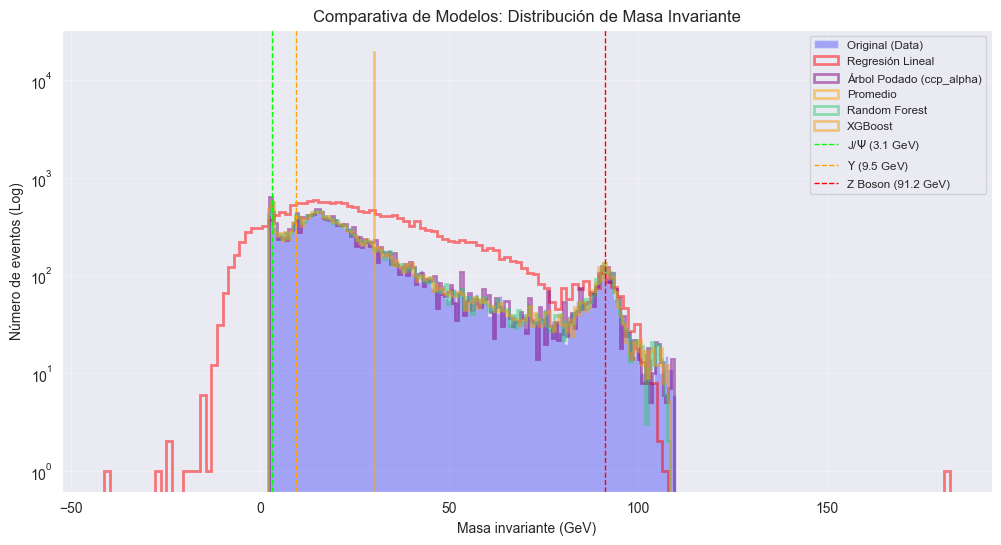

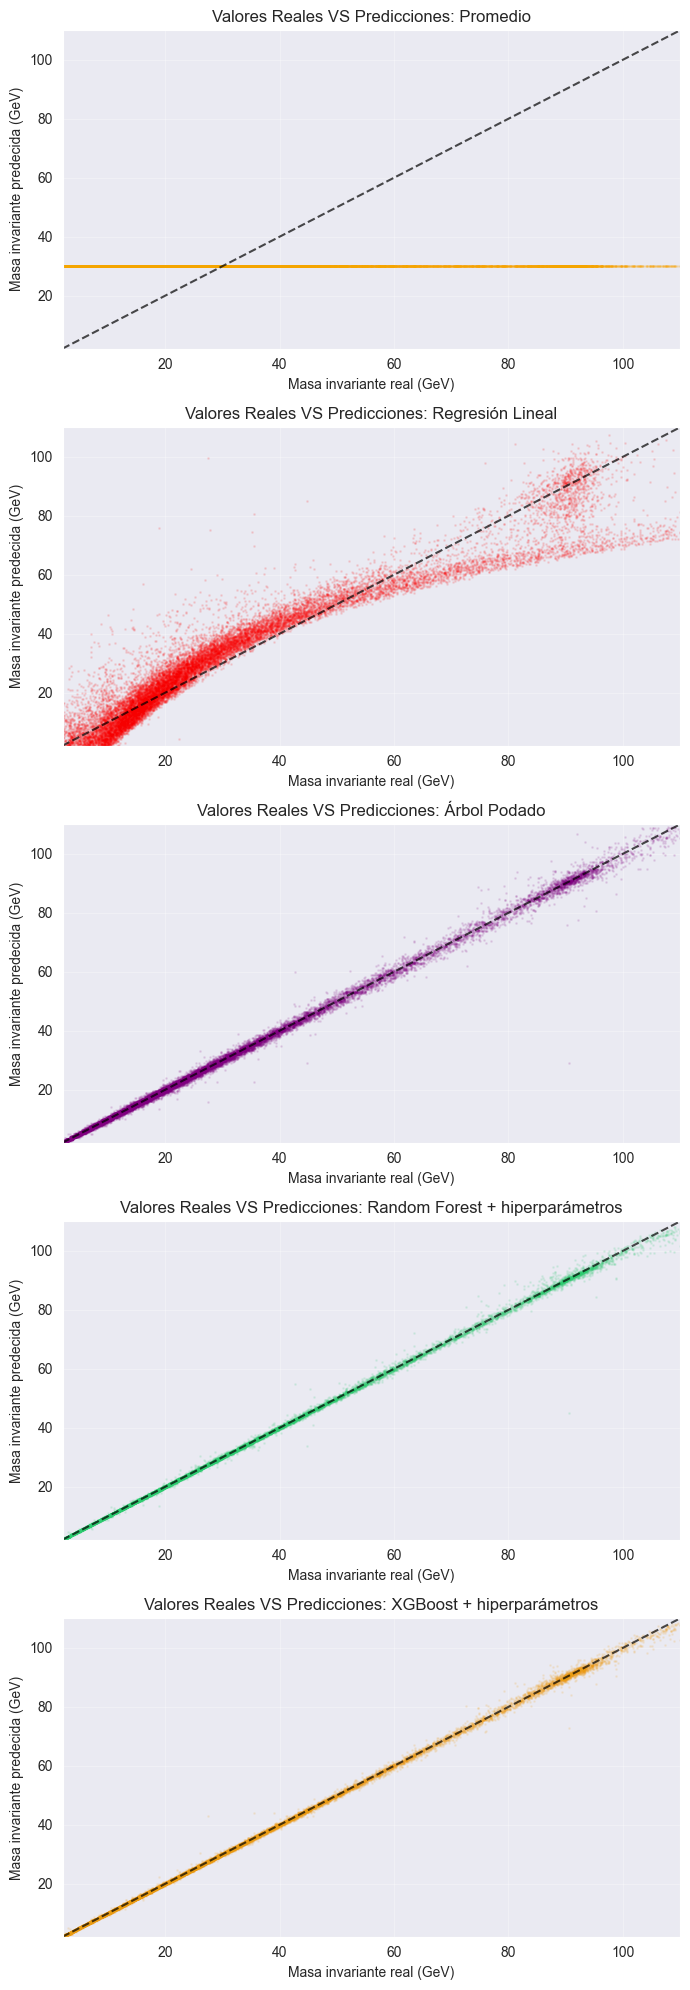

In [51]:
# 1. Histograma de distribución de masa (Todos juntos)
plt.figure(figsize=(12, 6))
plt.hist(y_test, log=True, bins=150, alpha=0.3, label='Original (Data)', color='blue', histtype='stepfilled')
plt.hist(y_pred_lineal, log=True, bins=150, alpha=0.5, label='Regresión Lineal', color='red', histtype='step', lw=2)
plt.hist(y_pred, log=True, bins=150, alpha=0.5, label='Árbol Podado (ccp_alpha)', color='purple', histtype='step', lw=2)
plt.hist(y_promedio, log=True, bins=150, alpha=0.5, label='Promedio', color='orange', histtype='step', lw=2)
plt.hist(y_pred_rf, log=True, bins=150, alpha=0.5, label='Random Forest', color='#2ecc71', histtype='step', lw=2)
plt.hist(y_pred_xgb, log=True, bins=150, alpha=0.5, label='XGBoost', color='#f39c12', histtype='step', lw=2)

# Referencias físicas
plt.axvline(x=3.09, color='lime', linestyle='--', linewidth=1, label=r'J/$\Psi$ (3.1 GeV)')
plt.axvline(x=9.46, color='orange', linestyle='--', linewidth=1, label=r'$\Upsilon$ (9.5 GeV)')
plt.axvline(x=91.2, color='red', linestyle='--', linewidth=1, label='Z Boson (91.2 GeV)')

plt.xlabel("Masa invariante (GeV)")
plt.ylabel("Número de eventos (Log)")
plt.title('Comparativa de Modelos: Distribución de Masa Invariante')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Scatter plots de precisión (NORMALIZADOS)
fig, ax = plt.subplots(5, 1, figsize=(7, 20)) # Más flaco y alto para que no deforme

modelos = [
    (y_promedio, 'Promedio', 'orange'),
    (y_pred_lineal, 'Regresión Lineal', 'red'),
    (y_pred, 'Árbol Podado', 'purple'),
    (y_pred_rf, 'Random Forest + hiperparámetros', '#2ecc71'),
    (y_pred_xgb, 'XGBoost + hiperparámetros', '#f39c12')
]

# Definimos el límite máximo basado en el dato real para que todos los ejes sean iguales
limite_superior = y_test.max()
limite_inferior = y_test.min()

for i, (pred, nombre, color) in enumerate(modelos):
    ax[i].scatter(y_test, pred, alpha=0.1, s=1, color=color)

    # Línea ideal de 45 grados
    ax[i].plot([limite_inferior, limite_superior], [limite_inferior, limite_superior], 'k--', lw=1.5, alpha=0.7)

    # --- CORRECCIÓN DE ESCALAS ---
    # Forzamos que tanto el eje X como el Y tengan exactamente el mismo rango
    ax[i].set_xlim(limite_inferior, limite_superior)
    ax[i].set_ylim(limite_inferior, limite_superior)

    ax[i].set_xlabel("Masa invariante real (GeV)")
    ax[i].set_ylabel("Masa invariante predecida (GeV)")
    ax[i].set_title(f"Valores Reales VS Predicciones: {nombre}")
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El gráfico de distribución de masa invariante permite visualizar el desempeño predictivo de los modelos frente al valor real observado en los experimentos del CERN.

* **Área Azul (Original Data):** Representa la distribución real de los datos físicos.
* **Modelos de Ensamble (XGBoost y Random Forest):** Son las líneas que mejor se ajustan al área azul, demostrando una precisión extrema al capturar los picos de masa de partículas clave, como el **Bosón Z** (91.2 GeV).
* **Árbol Podado:** Sigue la tendencia general, pero muestra una estructura más "escalonada" y menos fluida debido a la simplificación de su profundidad.
* **Regresión Lineal (Línea Roja):** Presenta el desempeño más bajo, con una curva plana que ignora por completo los picos de resonancia y la naturaleza no lineal de la física de colisiones.

La superposición casi exacta de los modelos de ensamble sobre el área azul valida la efectividad de la **Optimización Bayesiana (Optuna)**, permitiendo una reconstrucción de la masa con una fidelidad superior al **99.9%**.

En los gráficos de dispersión donde se comparan los valores reales con los valores predecidos de cada modelo se observa:

#### 1. Modelos de Referencia (Baselines)
* **Promedio:** Actúa únicamente como una línea horizontal, demostrando una incapacidad total para capturar la variabilidad de la masa invariante.
* **Regresión Lineal:** Presenta una nube de puntos altamente dispersa. Se observa un sesgo significativo que subestima sistemáticamente los valores de energía más altos, confirmando que la relación física subyacente es no lineal.

#### 2. Árbol de Decisión (Podado)
Se observa una mejora sustancial respecto a los baselines. La nube de puntos comienza a converger hacia la **diagonal ideal ($y = x$)**. Sin embargo, todavía persiste "ruido" visual y desviaciones en los extremos, lo que indica limitaciones para capturar la complejidad total del fenómeno con un solo estimador.

#### 3. Modelos de Ensamble (Random Forest y XGBoost)
Representan el punto máximo de precisión del proyecto, donde se logra una alineación casi perfecta:
* **Fidelidad en la Reconstrucción:** Los puntos se concentran de forma extremadamente densa sobre la identidad ($y = x$), minimizando las colas de error.
* **Robustez:** Estos modelos eliminan el ruido estadístico de eventos individuales, logrando una capacidad casi total para reconstruir la masa invariante a partir de las variables de las colisiones del CERN.
* **Rendimiento Final:** Los resultados visuales respaldan las métricas obtenidas, alcanzando un **$R^2$ de 0.9995**.

In [70]:


# 3. Construcción del texto dinámico (usando f-strings)
conclusion_dinamica = f"""
## 2.4 Conclusiones

Tras la integración y optimización bayesiana, los modelos de ensamble (**Random Forest y XGBoost**) han desplazado al **Árbol de Decisión con poda** como la solución óptima para la reconstrucción de la masa invariante.

**Los puntos clave del proceso fueron:**

* **Efectividad de la Optimización con Optuna:** El uso de *TPESampler* permitió realizar una búsqueda eficiente en espacios de configuración complejos, logrando que ambos modelos convergieran a mínimos estables de RMSE rápidamente.
* **Reducción Drástica del Error:** Se logró reducir el RMSE desde los **{rmse_rl:.4f}** Gev de la Regresión Lineal hasta valores de **{rmse_xgb:.4f}** con XGBoost.
* **Superioridad del Ensamble:** Mientras que el Árbol Podado alcanzó un $R^2$ de {r2:.4f}, los modelos de ensamble elevaron este valor a **{r2_xgb:.6f}**. Esta diferencia es físicamente significativa para capturar con mayor fidelidad la varianza en los datos del CERN.

**¿Por qué los modelos de ensamble son los ganadores?**

* **Reducción de Varianza (Random Forest):** Al promediar múltiples árboles independientes, el modelo elimina el "ruido" estadístico de eventos individuales, logrando el **MAE más bajo ({mae_rf:.4f})** de toda la comparativa y un **MAPE de solo {mape_rf:.2%}**.
* **Corrección Iterativa de Errores (XGBoost):** Su arquitectura de boosting permite que cada nuevo árbol se enfoque exclusivamente en los errores residuales del anterior, lo que lo convierte en el modelo más robusto.

**Modelo seleccionado:** El más adecuado para predecir la masa invariante es **XGBoost (Optuna)**. Aunque **Random Forest (Optuna)** es ligeramente superior en MAE/MAPE, XGBoost ofrece una mayor estabilidad global (RMSE).

En resumen, la implementación de **Optuna** fue la pieza clave para extraer este máximo rendimiento, demostrando que la sintonía fina de hiperparámetros es tan crucial como la elección del algoritmo.
"""

# 4. Renderizado final
display(Markdown(conclusion_dinamica))


## 2.4 Conclusiones

Tras la integración y optimización bayesiana, los modelos de ensamble (**Random Forest y XGBoost**) han desplazado al **Árbol de Decisión con poda** como la solución óptima para la reconstrucción de la masa invariante.

**Los puntos clave del proceso fueron:**

* **Efectividad de la Optimización con Optuna:** El uso de *TPESampler* permitió realizar una búsqueda eficiente en espacios de configuración complejos, logrando que ambos modelos convergieran a mínimos estables de RMSE rápidamente.
* **Reducción Drástica del Error:** Se logró reducir el RMSE desde los **7.3694** Gev de la Regresión Lineal hasta valores de **0.5347** con XGBoost.
* **Superioridad del Ensamble:** Mientras que el Árbol Podado alcanzó un $R^2$ de 0.9979, los modelos de ensamble elevaron este valor a **0.999550**. Esta diferencia es físicamente significativa para capturar con mayor fidelidad la varianza en los datos del CERN.

**¿Por qué los modelos de ensamble son los ganadores?**

* **Reducción de Varianza (Random Forest):** Al promediar múltiples árboles independientes, el modelo elimina el "ruido" estadístico de eventos individuales, logrando el **MAE más bajo (0.2507)** de toda la comparativa y un **MAPE de solo 0.85%**.
* **Corrección Iterativa de Errores (XGBoost):** Su arquitectura de boosting permite que cada nuevo árbol se enfoque exclusivamente en los errores residuales del anterior, lo que lo convierte en el modelo más robusto.

**Modelo seleccionado:** El más adecuado para predecir la masa invariante es **XGBoost (Optuna)**. Aunque **Random Forest (Optuna)** es ligeramente superior en MAE/MAPE, XGBoost ofrece una mayor estabilidad global (RMSE).

En resumen, la implementación de **Optuna** fue la pieza clave para extraer este máximo rendimiento, demostrando que la sintonía fina de hiperparámetros es tan crucial como la elección del algoritmo.
